# Análisis Exploratorio Inicial

Proyecto: **Clasificación de Cáncer de Mama**

En este notebook realizamos una primera exploración del dataset de cáncer de mama.

---


## 1. Importar librerías

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

sns.set(style="whitegrid")


## 2. Cargar el dataset

El archivo se asume en la ruta `data/raw/cancer_mama.csv` (puedes ajustar el nombre si es diferente).

In [2]:
ruta_dataset = Path("../data/raw/cancer_mama.csv")

if not ruta_dataset.exists():
    raise FileNotFoundError(f"No se encontró el archivo en: {ruta_dataset.resolve()}")

df = pd.read_csv(ruta_dataset)
print("✅ Datos cargados correctamente")
print(df.shape)
df.head()

✅ Datos cargados correctamente
(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 3. Información general del dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


## 4. Distribución de la variable objetivo

En este dataset la variable objetivo suele llamarse `diagnosis`, donde:
- `M` = maligno
- `B` = benigno

In [5]:
print(df["diagnosis"].value_counts())
print("\nProporciones:")
print(df["diagnosis"].value_counts(normalize=True))




diagnosis
B    357
M    212
Name: count, dtype: int64

Proporciones:
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


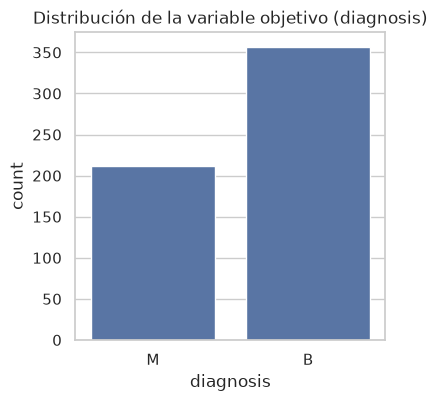

In [6]:
plt.figure(figsize=(4,4))
sns.countplot(x="diagnosis", data=df)
plt.title("Distribución de la variable objetivo (diagnosis)")
plt.show()

## 5. Valores faltantes

In [7]:
faltantes = df.isna().sum()
faltantes[faltantes > 0]

Unnamed: 32    569
dtype: int64

## 6. Correlación entre variables numéricas (visión general)

Aquí solo vemos un mapa de calor general para identificar posibles patrones.

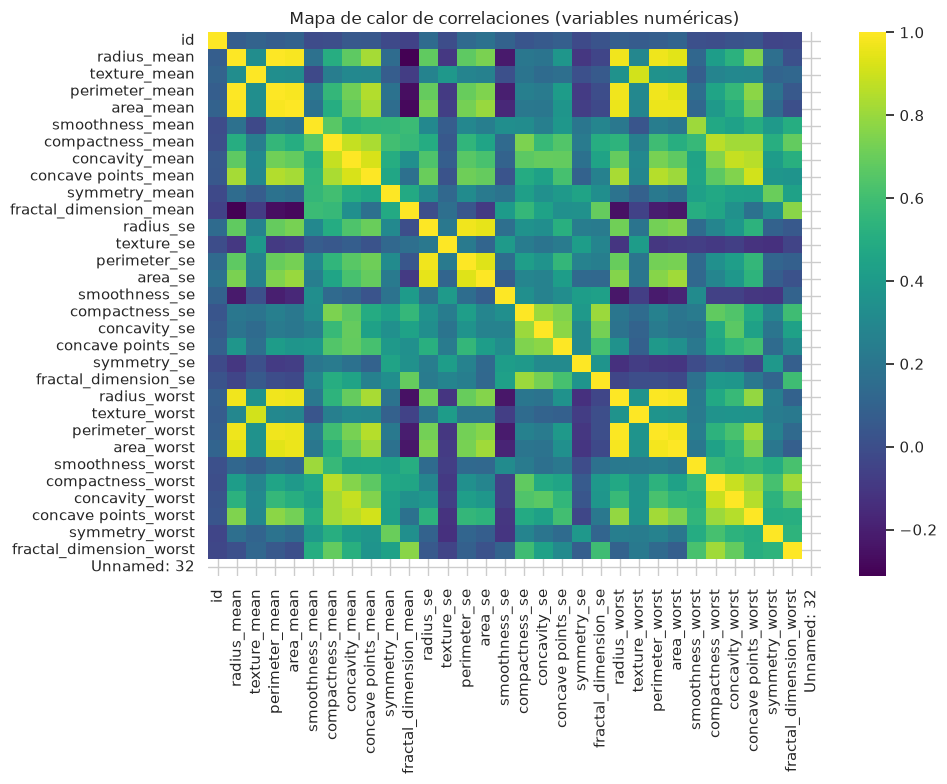

In [8]:
df_numericas = df.select_dtypes(include=["int64", "float64"])

if df_numericas.shape[1] > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_numericas.corr(), cmap="viridis")
    plt.title("Mapa de calor de correlaciones (variables numéricas)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes variables numéricas para calcular correlaciones.")

## 7. Conclusiones iniciales

- Revisar el balance de clases en `diagnosis`.
- Identificar posibles variables con valores extremos o muy correlacionadas.
- Detectar si hay valores faltantes que deban tratarse en la etapa de limpieza.

En el siguiente notebook realizaremos la **limpieza y preparación de los datos**.